# Bayesian Belief Updating: Discounting & Noise

# We initialise the simple model with a 3x3 likelihood matrix.
# Then, we create 100 data points, and plot on a 3D log graph.
# We use four permutations, Optimal Bayes, No-Noise + Discount, Noise + No-Discount, Noise + Discount
# We do a first trial (to write the code) on Sick 1
# Then we repeat 3x for Healthy, Sick1, and Sick2, creating a 3D Graph and a 2D graph of belief vectors four times for each permutation.
#




**States** $s \in \{0, 1, 2\}$: Healthy, Sickness 1, Sickness 2  
**Symptoms** $x \in \{0, 1, 2\}$: Cough, Sneeze, Whistle

Four models compared — isolating noise and discounting independently:
1. **Optimal Bayes** — no noise, no discounting
2. **No-noise + Discounted** — clean updates, exponential forgetting ($\alpha < 1$)
3. **Noisy, no discounting** — perturbed updates, full accumulation ($\alpha = 1$)
4. **Noisy + Discounted** — perturbed updates with exponential forgetting

In [208]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from scipy.special import logsumexp


In [209]:
# ── Parameters ──────────────────────────────────────────────────────────────
np.random.seed(42)

STATES   = ['Healthy', 'Sickness 1', 'Sickness 2']
SYMPTOMS = ['Cough', 'Sneeze', 'Whistle']
T        = 100       # number of observations
TRUE_S   = 1         # true hidden state (Sickness 1)
SIGMA    = 0.5       # noise std σ for noisy model
ALPHA    = 0.9      # exponential discounting factor α

# ── Prior  p(s) ─────────────────────────────────────────────────────────────
prior = np.array([1/3, 1/3, 1/3])

# ── Likelihood  L[x, s] = P(symptom x | state s) ───────────────────────────
# Rows = symptoms {0:Cough, 1:Sneeze, 2:Whistle}
# Cols = states   {0:Healthy, 1:Sickness1, 2:Sickness2}
# Each *column* sums to 1.
#
# Structure: x=0.55, y=1/3, z=0.15
#   Sick1   = (x,   y,   1-(x+y))   — Sneeze is neutral (=1/3) for Sick1
#   Sick2   = (y,   x,   1-(x+y))   — Cough  is neutral (=1/3) for Sick2
#   Healthy = (z,   z,   1-2z    )  — symmetric

x, y, z = 0.4, 1/3, 0.15

#              Healthy   Sick1        Sick2
L = np.array([[z,        x,           y          ],   # Cough
              [z,        y,           x          ],   # Sneeze
              [1 - 2*z,  1 - (x + y), 1 - (y + x)]])  # Whistle

assert np.allclose(L.sum(axis=0), 1.0), "Each column of L must sum to 1"
assert np.all(L > 0), "All likelihoods must be positive"

print(f'Parameters: x={x}, y={y:.4f} (=1/3), z={z}')
print('Prior p(s):', dict(zip(STATES, prior.round(4))))
print('\nLikelihood matrix P(x|s):')
print('         ', '  '.join(f'{s:>10}' for s in STATES))
for i, sym in enumerate(SYMPTOMS):
    print(f'{sym:<8}', '  '.join(f'{L[i,j]:>10.4f}' for j in range(3)))

Parameters: x=0.4, y=0.3333 (=1/3), z=0.15
Prior p(s): {'Healthy': np.float64(0.3333), 'Sickness 1': np.float64(0.3333), 'Sickness 2': np.float64(0.3333)}

Likelihood matrix P(x|s):
             Healthy  Sickness 1  Sickness 2
Cough        0.1500      0.4000      0.3333
Sneeze       0.1500      0.3333      0.4000
Whistle      0.7000      0.2667      0.2667


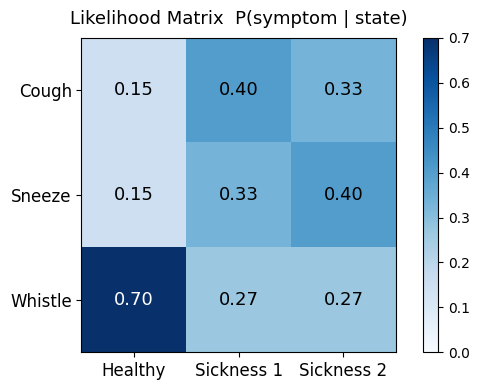

In [210]:
# ── Likelihood heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(L, vmin=0, vmax=0.7, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(STATES, fontsize=12)
ax.set_yticks(range(3)); ax.set_yticklabels(SYMPTOMS, fontsize=12)
ax.set_title('Likelihood Matrix  P(symptom | state)', fontsize=13, pad=10)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{L[i,j]:.2f}', ha='center', va='center',
                fontsize=13, color='black' if L[i,j] < 0.45 else 'white')
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

In [211]:
# ── Generate observations from the true state ────────────────────────────────
data = np.random.choice(3, size=T, p=L[:, TRUE_S])

print(f'True state : {STATES[TRUE_S]}')
print(f'Observations (all {T}): {data}')
print(f'Symptom counts — Cough: {(data==0).sum()}, '
      f'Sneeze: {(data==1).sum()}, Whistle: {(data==2).sum()}')

True state : Sickness 1
Observations (all 100): [0 2 1 1 0 0 0 2 1 1 0 2 2 0 0 0 0 1 1 0 1 0 0 0 1 2 0 1 1 0 1 0 0 2 2 2 0
 0 1 1 0 1 0 2 0 1 0 1 1 0 2 2 2 2 1 2 0 0 0 0 0 0 2 0 0 1 0 2 0 2 2 0 0 2
 1 1 2 0 0 0 2 1 0 0 0 0 1 1 2 1 0 1 2 1 2 1 1 1 0 0]
Symptom counts — Cough: 46, Sneeze: 30, Whistle: 24


In [212]:
# ── Belief update algorithms ─────────────────────────────────────────────────

def norm_log(lp):
    """Subtract log-sum-exp so that exp(lp) sums to 1."""
    return lp - logsumexp(lp)

log_prior = norm_log(np.log(prior))
times     = np.arange(T + 1)

# ── Model 1: Optimal Bayesian ────────────────────────────────────────────────
log_b_opt = np.zeros((T + 1, 3))
log_b_opt[0] = log_prior
for t in range(1, T + 1):
    x = data[t - 1]
    log_b_opt[t] = norm_log(log_b_opt[t - 1] + np.log(L[x]))

# ── Model 2: No-noise + Discounted ───────────────────────────────────────────
# Clean log-likelihoods, exponential discounting: disc_t = log P(x_t|s) + α·disc_{t-1}
log_b_disc = np.zeros((T + 1, 3))
log_b_disc[0] = log_prior
disc = np.zeros(3)
for t in range(1, T + 1):
    x = data[t - 1]
    disc = np.log(L[x]) + ALPHA * disc
    log_b_disc[t] = norm_log(log_prior + disc)

# ── Model 3: Noisy, no discounting (α = 1) ──────────────────────────────────
# Perturbed log-likelihoods, full accumulation
rng1 = np.random.default_rng(42)
log_b_noisy = np.zeros((T + 1, 3))
log_b_noisy[0] = log_prior
for t in range(1, T + 1):
    x = data[t - 1]
    noisy_lik = np.log(L[x]) + rng1.normal(0, SIGMA, 3)
    log_b_noisy[t] = norm_log(log_b_noisy[t - 1] + noisy_lik)

# ── Model 4: Noisy + Discounted ──────────────────────────────────────────────
# Perturbed log-likelihoods with exponential discounting
rng2 = np.random.default_rng(99)
log_b_noisy_disc = np.zeros((T + 1, 3))
log_b_noisy_disc[0] = log_prior
disc_n = np.zeros(3)
for t in range(1, T + 1):
    x = data[t - 1]
    noisy_lik = np.log(L[x]) + rng2.normal(0, SIGMA, 3)
    disc_n = noisy_lik + ALPHA * disc_n
    log_b_noisy_disc[t] = norm_log(log_prior + disc_n)

print(f'Final posteriors at t={T}:')
for label, lb in [('Optimal              ', log_b_opt),
                  ('No-noise + Discounted', log_b_disc),
                  ('Noisy (no disc.)     ', log_b_noisy),
                  ('Noisy + Discounted   ', log_b_noisy_disc)]:
    p = np.exp(lb[-1]).round(3)
    print(f'  {label}: {dict(zip(STATES, p))}')

Final posteriors at t=100:
  Optimal              : {'Healthy': np.float64(0.0), 'Sickness 1': np.float64(0.949), 'Sickness 2': np.float64(0.051)}
  No-noise + Discounted: {'Healthy': np.float64(0.002), 'Sickness 1': np.float64(0.469), 'Sickness 2': np.float64(0.529)}
  Noisy (no disc.)     : {'Healthy': np.float64(0.0), 'Sickness 1': np.float64(0.998), 'Sickness 2': np.float64(0.002)}
  Noisy + Discounted   : {'Healthy': np.float64(0.004), 'Sickness 1': np.float64(0.198), 'Sickness 2': np.float64(0.798)}


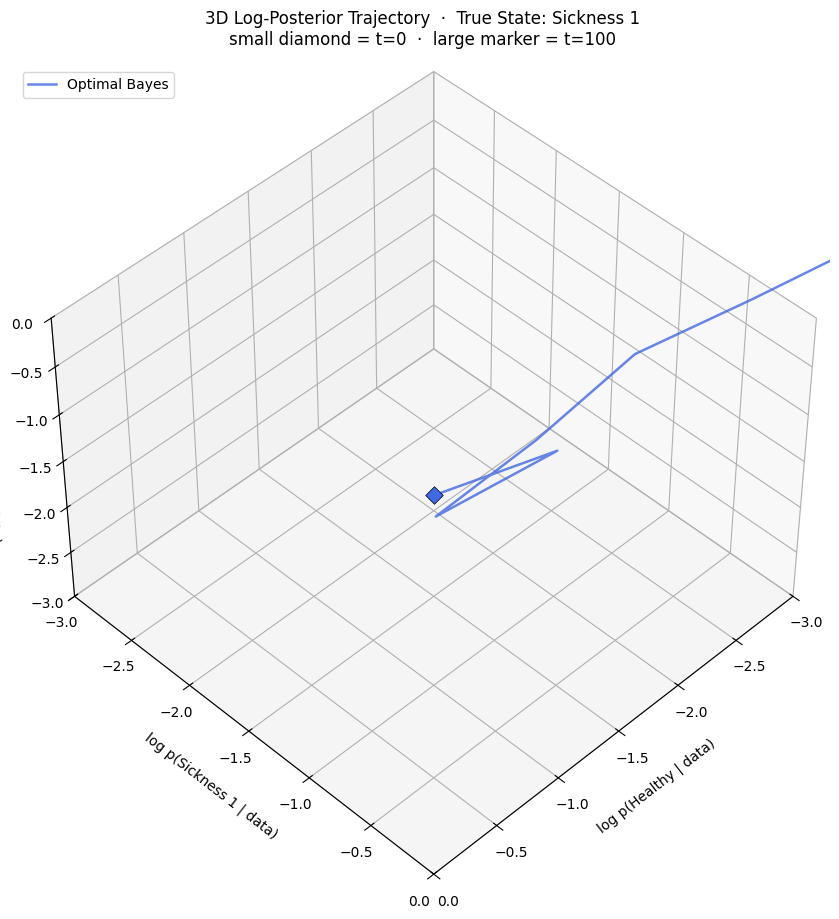

In [213]:
# ── 3D Log-Posterior Trajectory ──────────────────────────────────────────────
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

ax.plot(log_b_opt[:, 0], log_b_opt[:, 1], log_b_opt[:, 2],
        label='Optimal Bayes', color='royalblue', alpha=0.80, lw=1.8)
ax.scatter(*log_b_opt[0],  color='royalblue', marker='D', s=80,  zorder=5, edgecolors='k', lw=0.5)
ax.scatter(*log_b_opt[-1], color='royalblue', marker='D', s=200, zorder=5, edgecolors='k', lw=0.5)

ax.set_xlim(-3, 0)
ax.set_ylim(-3, 0)
ax.set_zlim(-3,0)
ax.set_xlabel('log p(Healthy | data)',     labelpad=10)
ax.set_ylabel('log p(Sickness 1 | data)', labelpad=10)
ax.set_zlabel('log p(Sickness 2 | data)', labelpad=10)
ax.set_title(f'3D Log-Posterior Trajectory  ·  True State: {STATES[TRUE_S]}\n'
             'small diamond = t=0  ·  large marker = t=100', pad=15)
ax.legend(loc='upper left', fontsize=10)
ax.view_init(elev=45, azim=45)
plt.tight_layout()
plt.show()

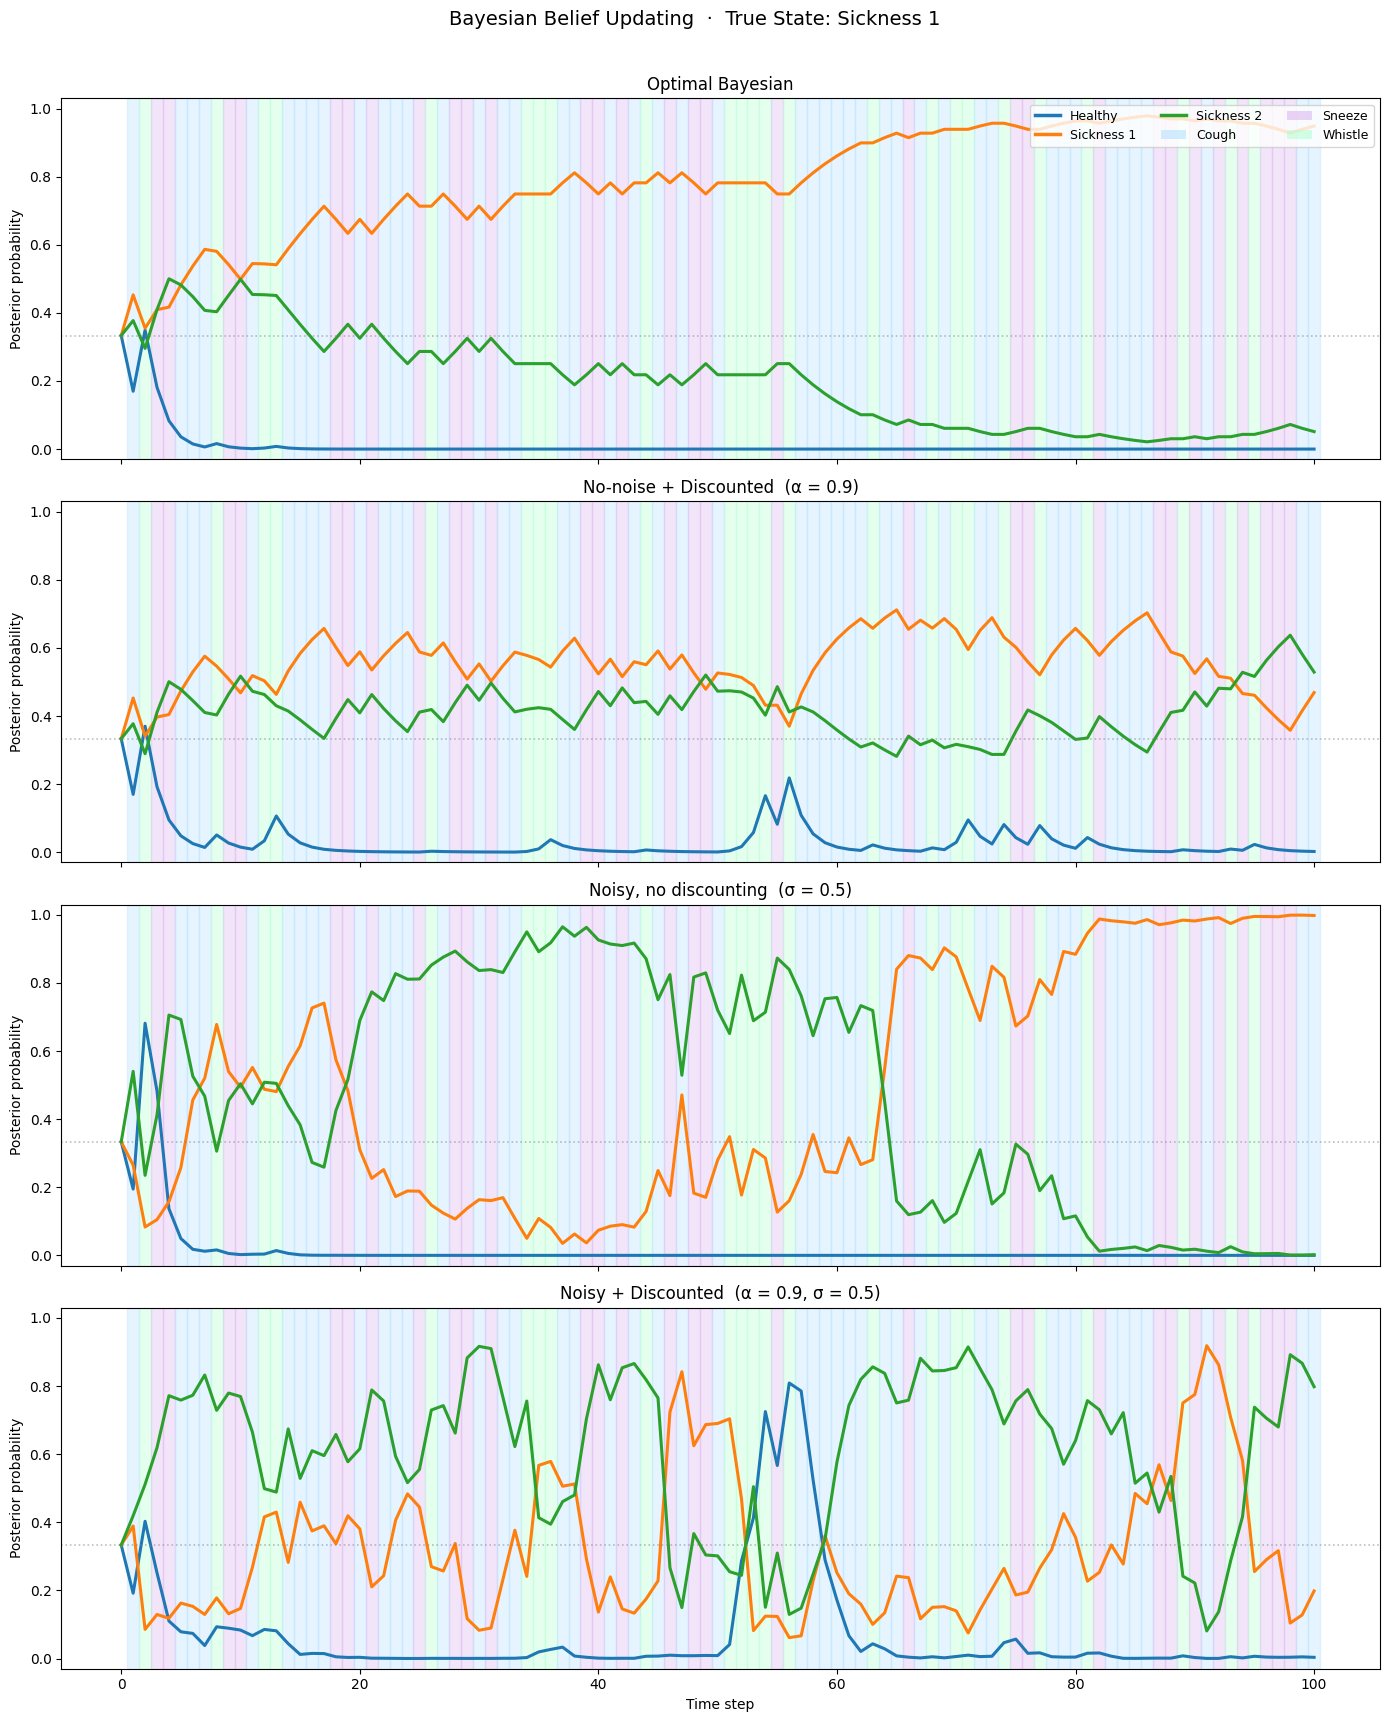

In [214]:
# ── 2D Posterior Probability Traces ─────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 17), sharex=True)

model_cfg = [
    (log_b_opt,        'Optimal Bayesian'),
    (log_b_disc,       f'No-noise + Discounted  (α = {ALPHA})'),
    (log_b_noisy,      f'Noisy, no discounting  (σ = {SIGMA})'),
    (log_b_noisy_disc, f'Noisy + Discounted  (α = {ALPHA}, σ = {SIGMA})'),
]
state_cols   = ['tab:blue', 'tab:orange', 'tab:green']
symptom_cols = ['#AADDFF', '#D8AAEE', '#AAFFCC']

for ax, (log_b, title) in zip(axes, model_cfg):
    for t_i, x_i in enumerate(data):
        ax.axvspan(t_i + 0.5, t_i + 1.5, color=symptom_cols[x_i], alpha=0.30)
    probs = np.exp(log_b)
    for s, (state, col) in enumerate(zip(STATES, state_cols)):
        ax.plot(times, probs[:, s], label=state, color=col, lw=2.2)
    ax.axhline(1/3, color='gray', ls=':', alpha=0.5, lw=1.2)
    ax.set_ylabel('Posterior probability')
    ax.set_title(title, fontsize=12)
    ax.set_ylim(-0.03, 1.03)

state_lines  = [plt.Line2D([0],[0], color=c, lw=2.5, label=s)
                for c, s in zip(state_cols, STATES)]
sym_patches  = [mpatches.Patch(facecolor=c, alpha=0.5, label=s)
                for c, s in zip(symptom_cols, SYMPTOMS)]
axes[0].legend(handles=state_lines + sym_patches, loc='upper right', ncol=3, fontsize=9)

axes[-1].set_xlabel('Time step')
plt.suptitle(f'Bayesian Belief Updating  ·  True State: {STATES[TRUE_S]}',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


────────────────────────────────────────────────────────────
  True state: Healthy
  Symptom counts — Cough: 15, Sneeze: 10, Whistle: 75
  Optimal Bayes                            final: [1. 0. 0.]
  No-noise+Disc. (α=0.9)                   final: [0.997 0.002 0.001]
  Noisy, no disc. (σ=0.5)                  final: [1. 0. 0.]
  Noisy+Disc. (α=0.9, σ=0.5)               final: [0.998 0.    0.001]


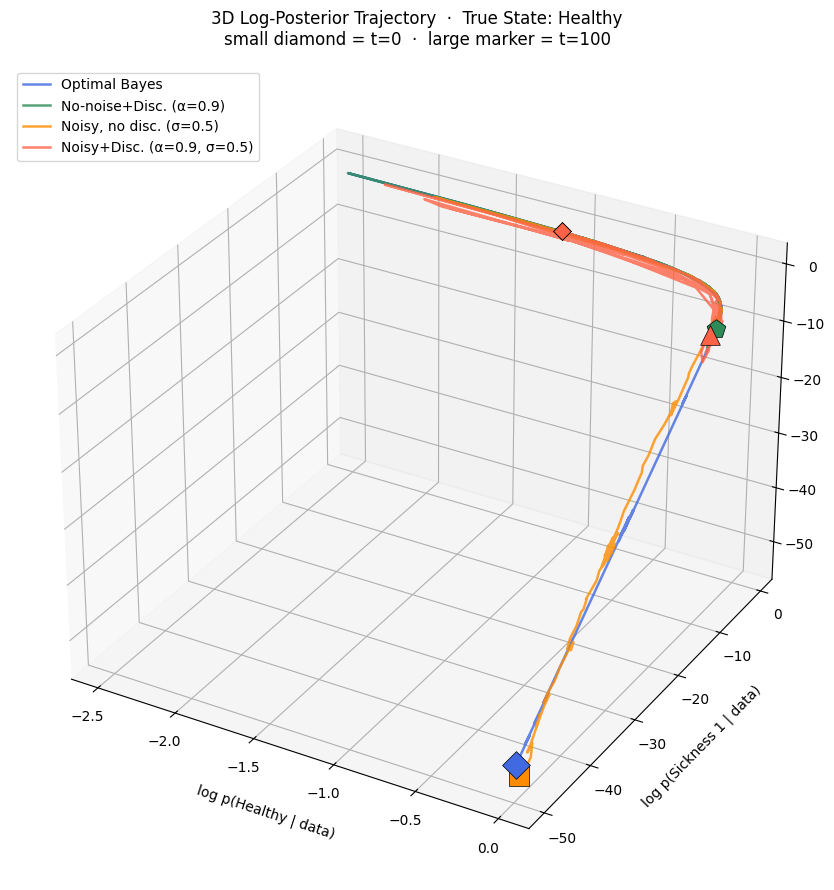

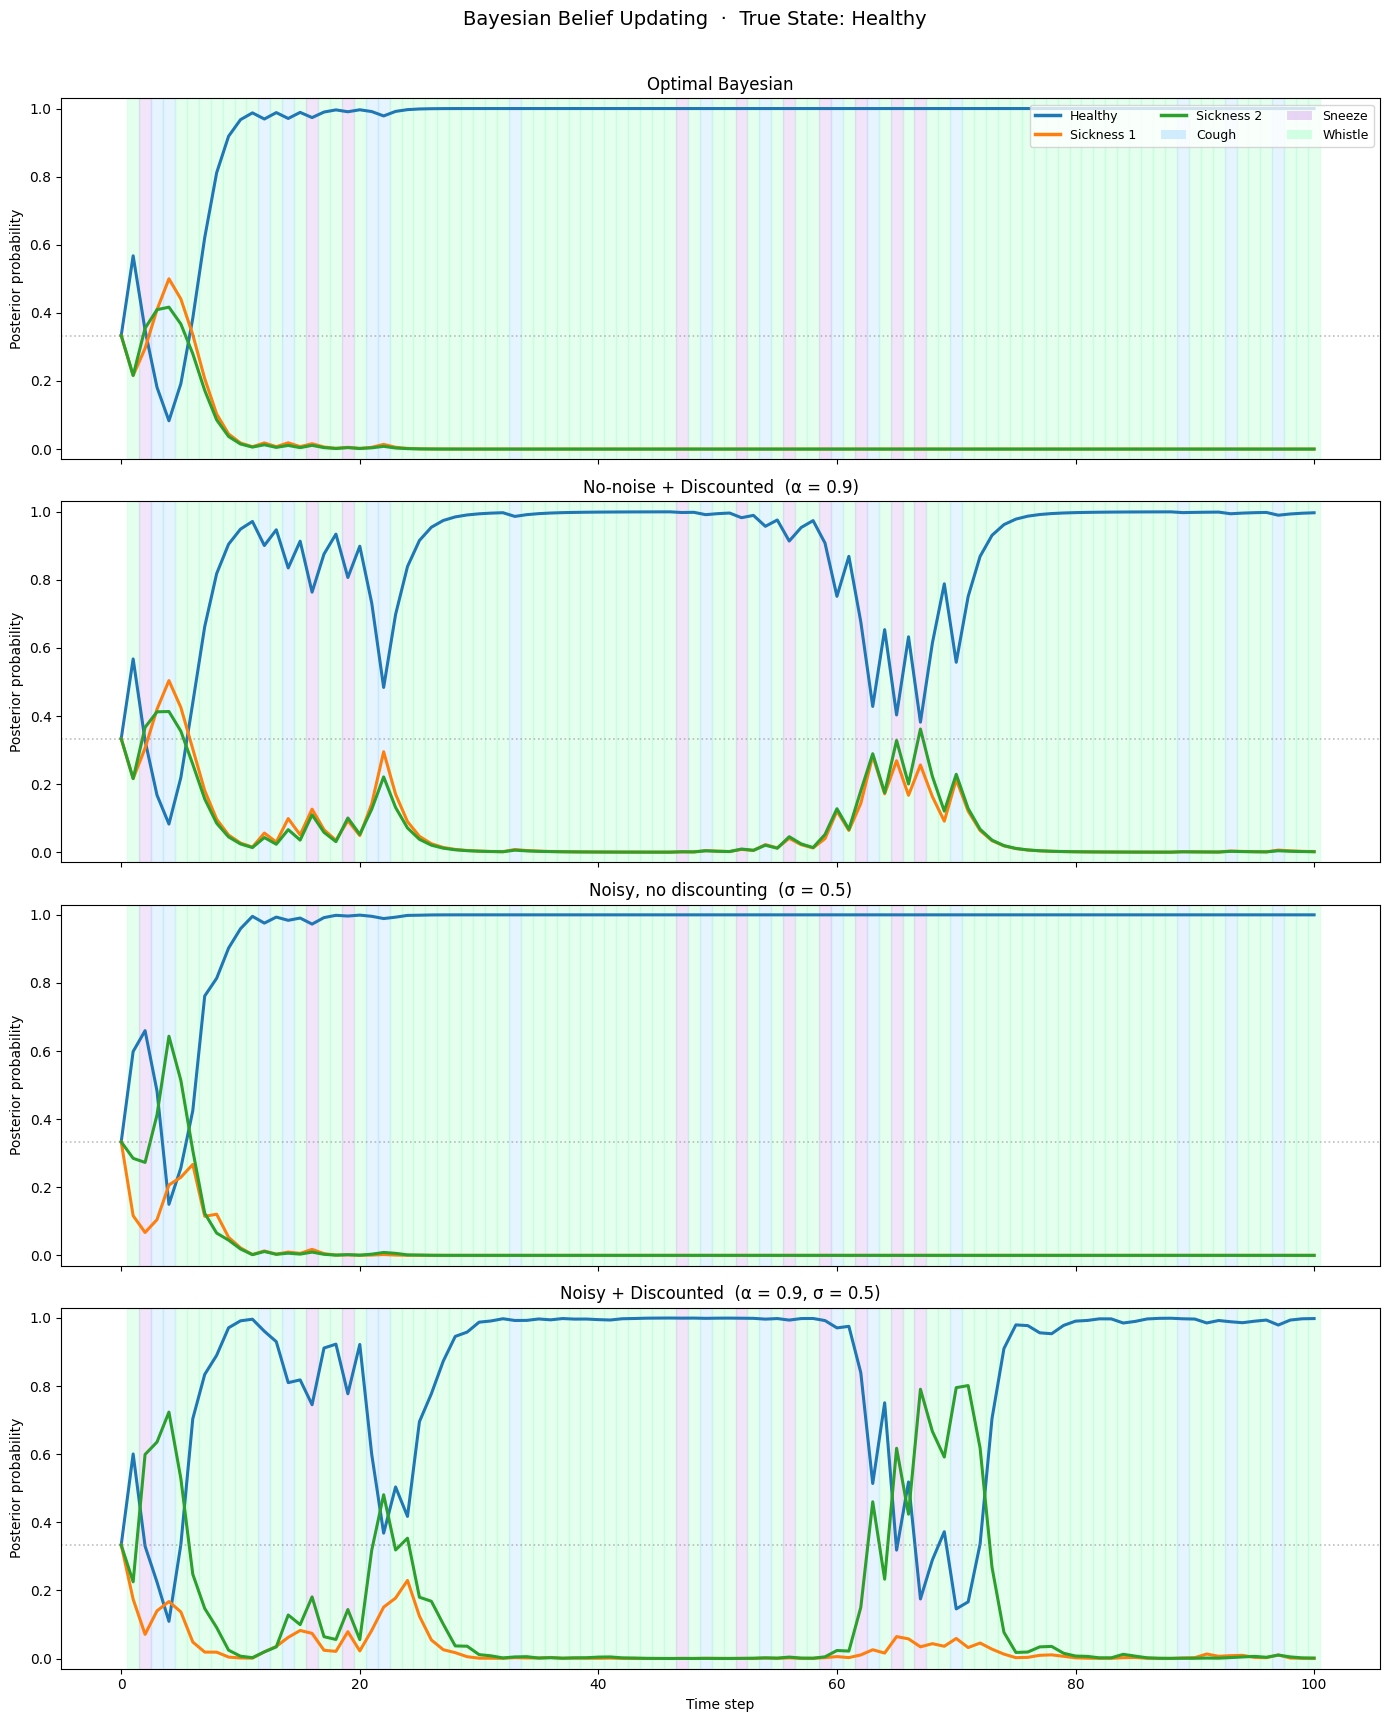


────────────────────────────────────────────────────────────
  True state: Sickness 1
  Symptom counts — Cough: 42, Sneeze: 33, Whistle: 25
  Optimal Bayes                            final: [0.    0.838 0.162]
  No-noise+Disc. (α=0.9)                   final: [0.002 0.651 0.347]
  Noisy, no disc. (σ=0.5)                  final: [0. 0. 1.]
  Noisy+Disc. (α=0.9, σ=0.5)               final: [0.008 0.856 0.136]


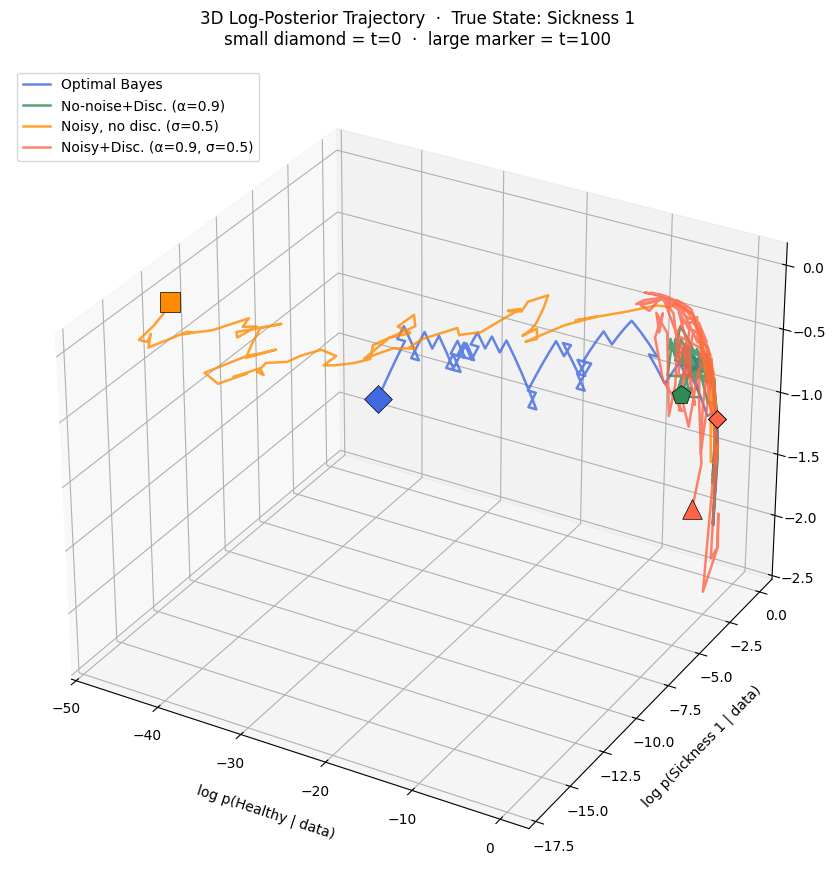

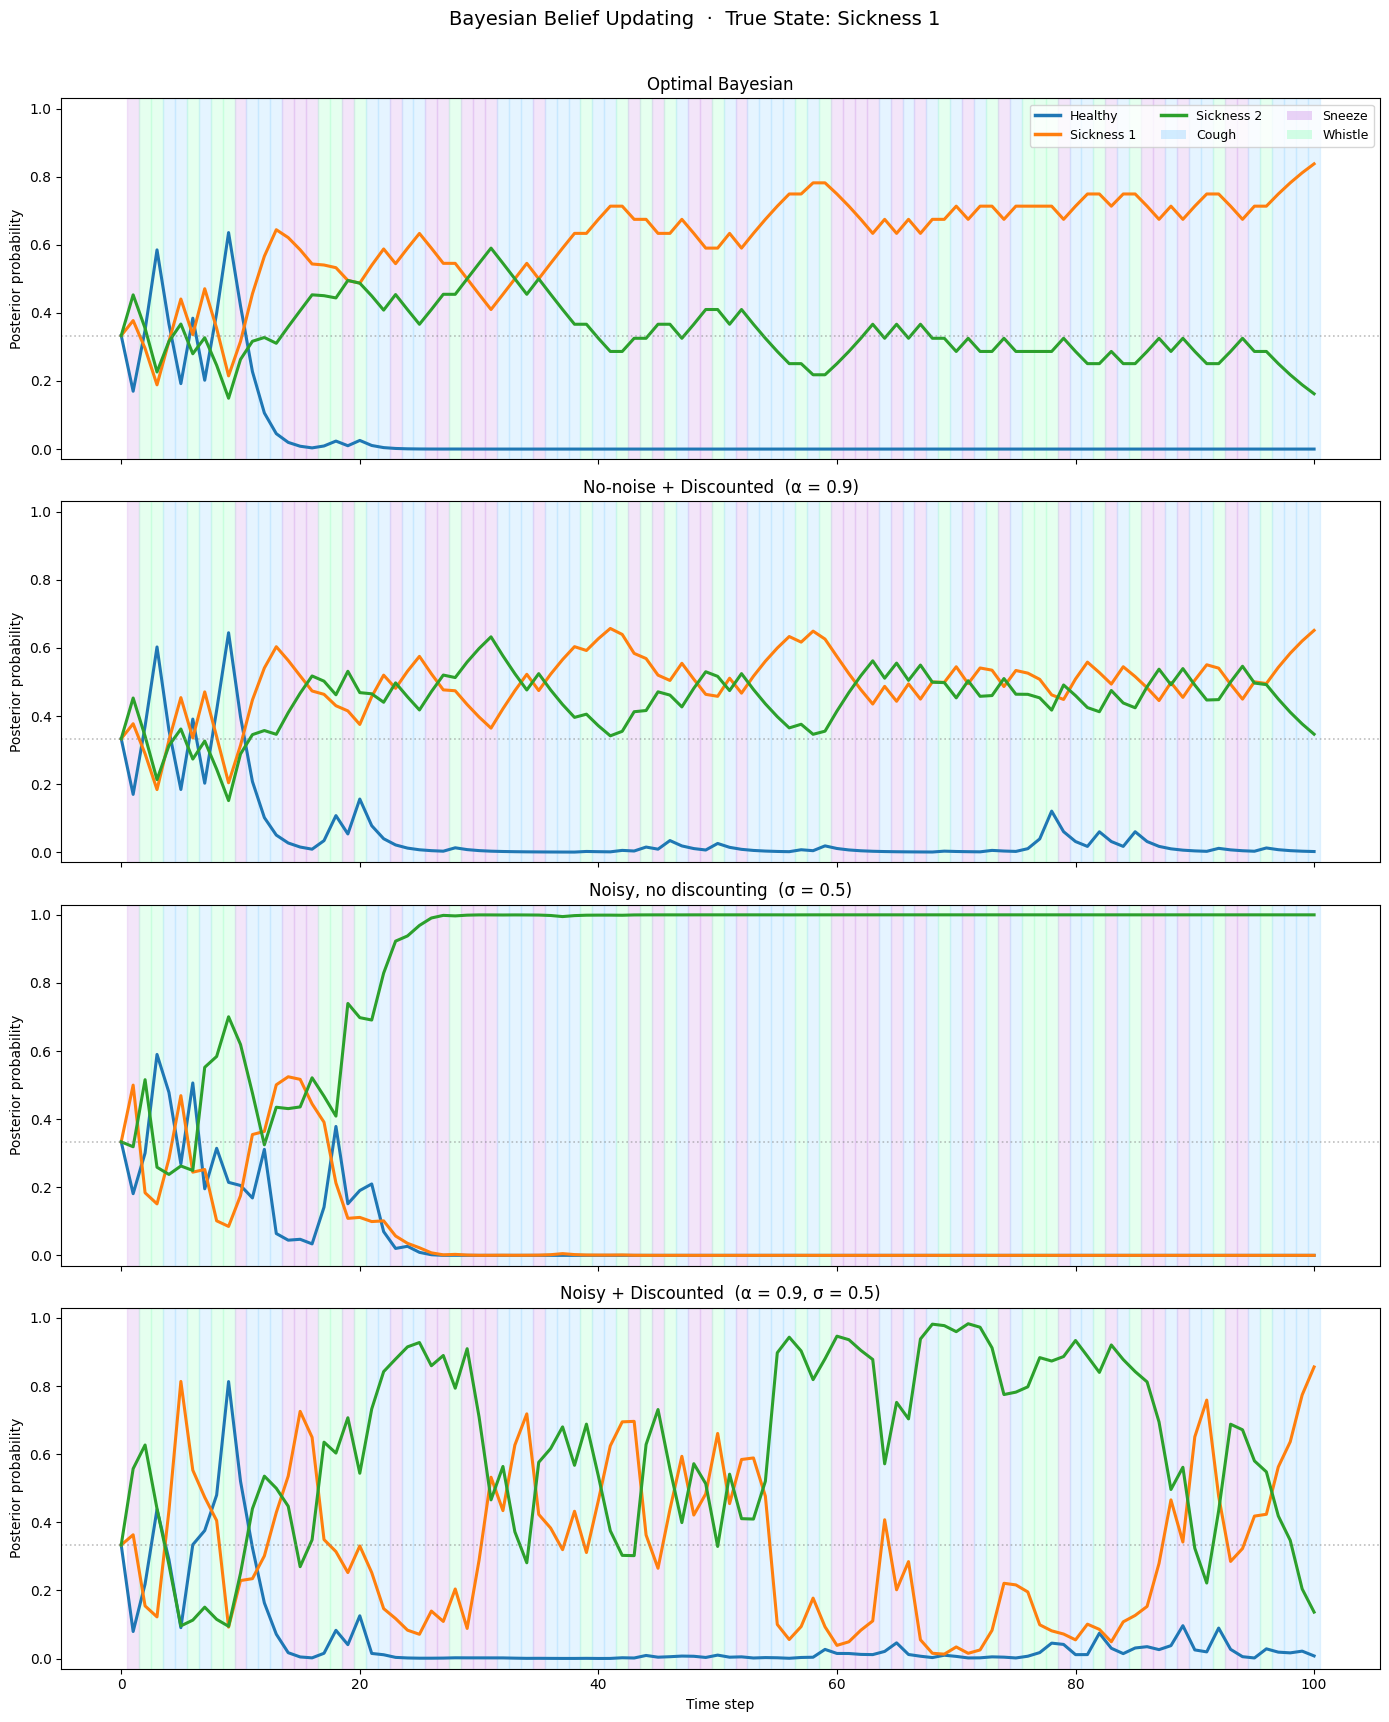


────────────────────────────────────────────────────────────
  True state: Sickness 2
  Symptom counts — Cough: 31, Sneeze: 39, Whistle: 30
  Optimal Bayes                            final: [0.    0.189 0.811]
  No-noise+Disc. (α=0.9)                   final: [0.001 0.497 0.502]
  Noisy, no disc. (σ=0.5)                  final: [0.    0.812 0.188]
  Noisy+Disc. (α=0.9, σ=0.5)               final: [0.    0.153 0.847]


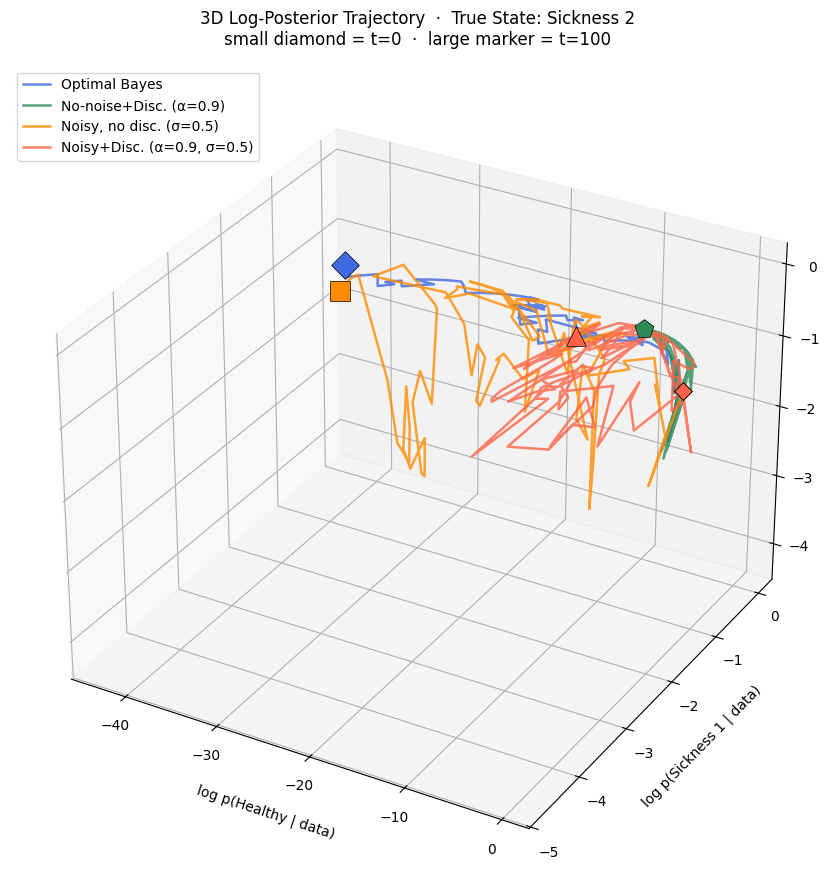

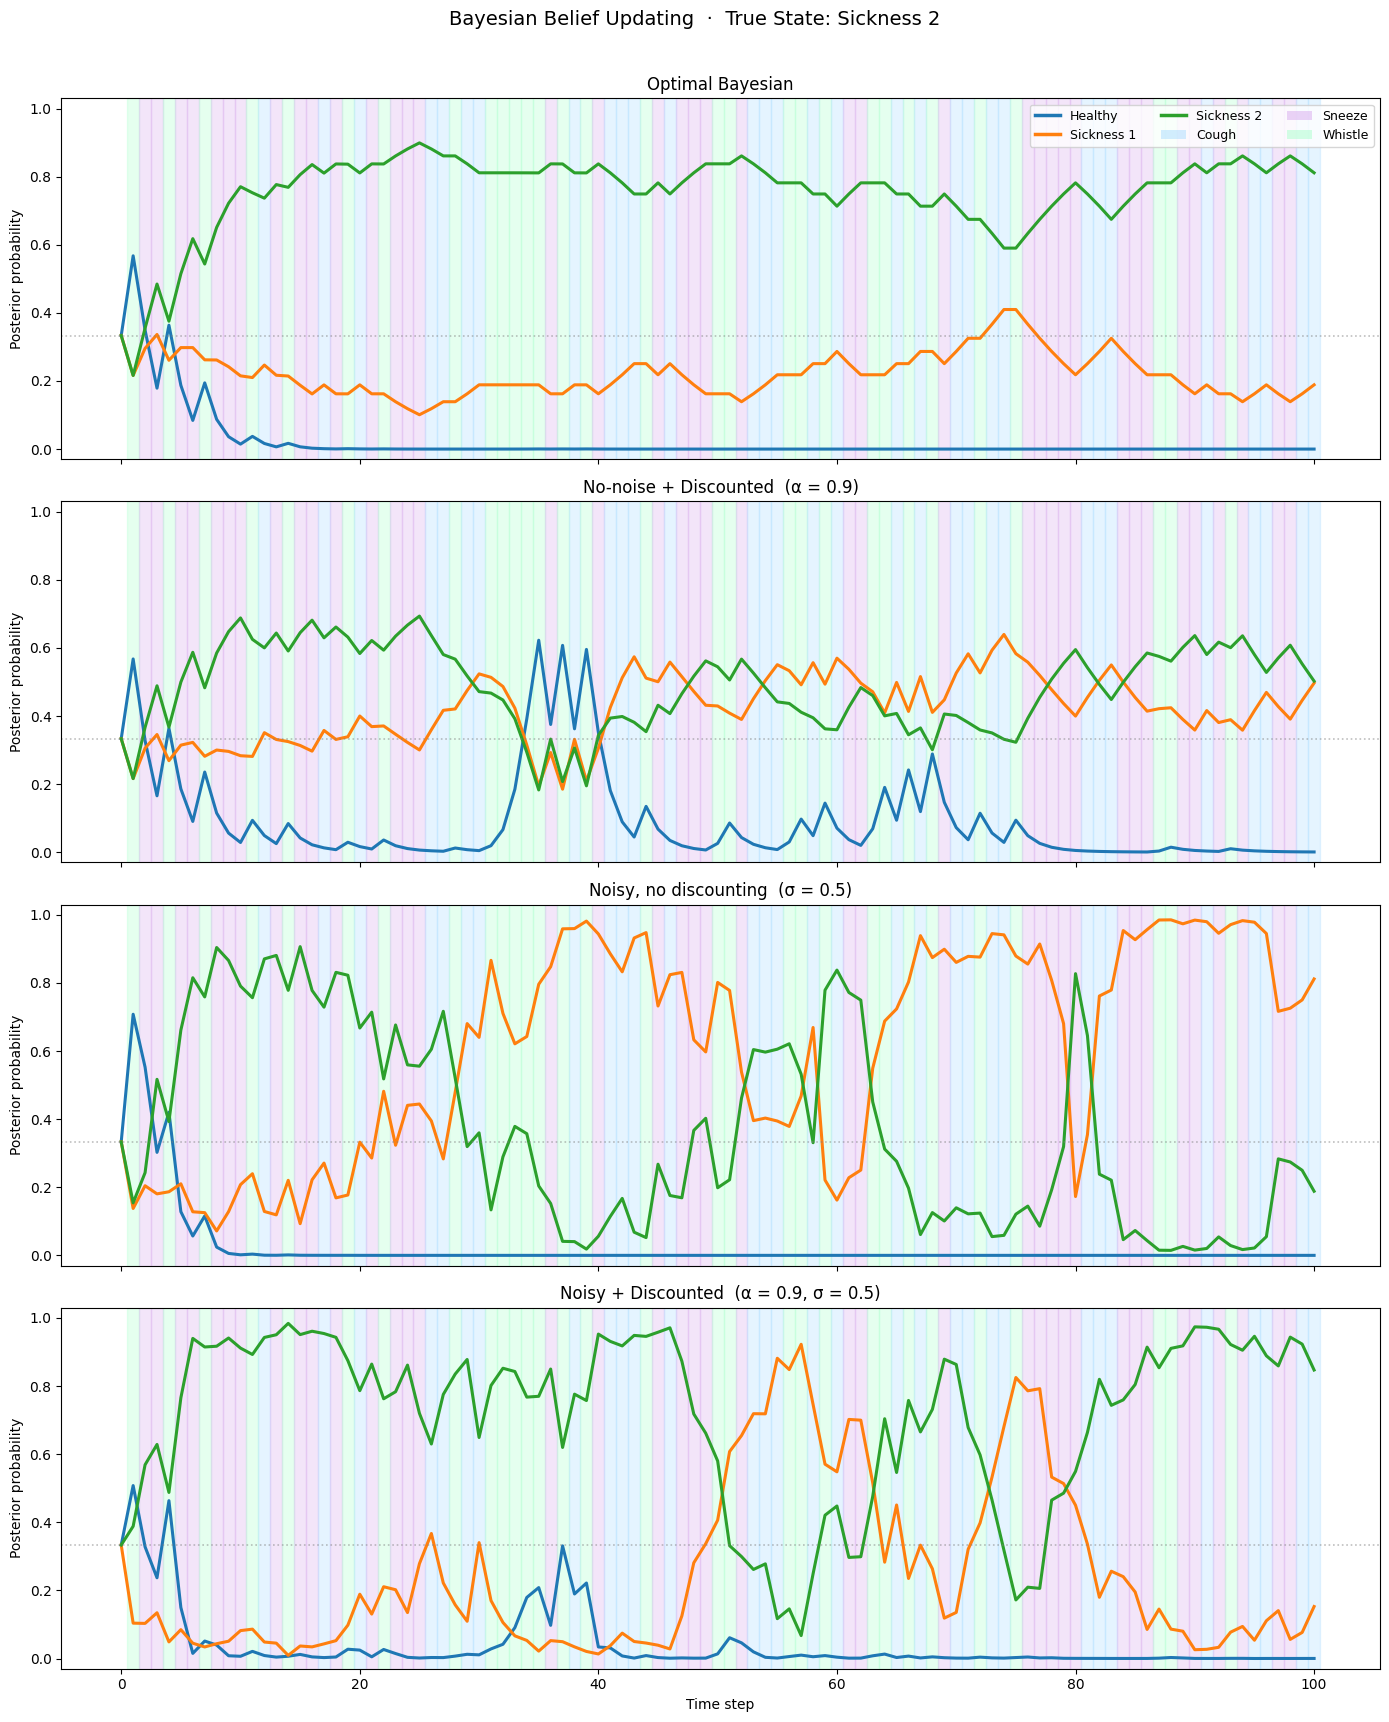

In [215]:
# ── All three true states ────────────────────────────────────────────────────
state_cols   = ['tab:blue', 'tab:orange', 'tab:green']
symptom_cols = ['#AADDFF', '#D8AAEE', '#AAFFCC']

for true_s in range(3):

    rng_data = np.random.default_rng(true_s * 7)
    obs = rng_data.choice(3, size=T, p=L[:, true_s])

    # Model 1: Optimal
    lb_opt = np.zeros((T + 1, 3)); lb_opt[0] = log_prior
    for t in range(1, T + 1):
        lb_opt[t] = norm_log(lb_opt[t - 1] + np.log(L[obs[t - 1]]))

    # Model 2: No-noise + Discounted
    lb_disc = np.zeros((T + 1, 3)); lb_disc[0] = log_prior
    disc = np.zeros(3)
    for t in range(1, T + 1):
        disc = np.log(L[obs[t - 1]]) + ALPHA * disc
        lb_disc[t] = norm_log(log_prior + disc)

    # Model 3: Noisy, no discounting
    rng1 = np.random.default_rng(42 + true_s)
    lb_noisy = np.zeros((T + 1, 3)); lb_noisy[0] = log_prior
    for t in range(1, T + 1):
        lb_noisy[t] = norm_log(lb_noisy[t - 1] + np.log(L[obs[t - 1]]) + rng1.normal(0, SIGMA, 3))

    # Model 4: Noisy + Discounted
    rng2 = np.random.default_rng(99 + true_s)
    lb_nd = np.zeros((T + 1, 3)); lb_nd[0] = log_prior
    disc_n = np.zeros(3)
    for t in range(1, T + 1):
        disc_n = (np.log(L[obs[t - 1]]) + rng2.normal(0, SIGMA, 3)) + ALPHA * disc_n
        lb_nd[t] = norm_log(log_prior + disc_n)

    models = [
        (lb_opt,   'Optimal Bayes',                      'royalblue',  'D'),
        (lb_disc,  f'No-noise+Disc. (α={ALPHA})',         'seagreen',   'p'),
        (lb_noisy, f'Noisy, no disc. (σ={SIGMA})',        'darkorange', 's'),
        (lb_nd,    f'Noisy+Disc. (α={ALPHA}, σ={SIGMA})', 'tomato',     '^'),
    ]

    print(f"\n{'─'*60}")
    print(f"  True state: {STATES[true_s]}")
    print(f"  Symptom counts — Cough: {(obs==0).sum()}, Sneeze: {(obs==1).sum()}, Whistle: {(obs==2).sum()}")
    for lb, label, *_ in models:
        print(f"  {label:<40} final: {np.exp(lb[-1]).round(3)}")

    # ── 3D plot ───────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 9))
    ax  = fig.add_subplot(111, projection='3d')
    for lb, label, col, mk in models:
        ax.plot(lb[:, 0], lb[:, 1], lb[:, 2], label=label, color=col, alpha=0.80, lw=1.8)
        ax.scatter(*lb[0],  color=col, marker='D', s=80,  zorder=5, edgecolors='k', lw=0.5)
        ax.scatter(*lb[-1], color=col, marker=mk,  s=200, zorder=5, edgecolors='k', lw=0.5)
    ax.set_xlabel('log p(Healthy | data)',     labelpad=10)
    ax.set_ylabel('log p(Sickness 1 | data)', labelpad=10)
    ax.set_zlabel('log p(Sickness 2 | data)', labelpad=10)
    ax.set_title(f'3D Log-Posterior Trajectory  ·  True State: {STATES[true_s]}\n'
                 'small diamond = t=0  ·  large marker = t=100', pad=15)
    ax.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()

    # ── 2D plot ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(4, 1, figsize=(14, 17), sharex=True)
    model_cfg = [
        (lb_opt,   'Optimal Bayesian'),
        (lb_disc,  f'No-noise + Discounted  (α = {ALPHA})'),
        (lb_noisy, f'Noisy, no discounting  (σ = {SIGMA})'),
        (lb_nd,    f'Noisy + Discounted  (α = {ALPHA}, σ = {SIGMA})'),
    ]
    for ax, (lb, title) in zip(axes, model_cfg):
        for t_i, x_i in enumerate(obs):
            ax.axvspan(t_i + 0.5, t_i + 1.5, color=symptom_cols[x_i], alpha=0.30)
        probs = np.exp(lb)
        for s, (state, col) in enumerate(zip(STATES, state_cols)):
            ax.plot(times, probs[:, s], label=state, color=col, lw=2.2)
        ax.axhline(1/3, color='gray', ls=':', alpha=0.5, lw=1.2)
        ax.set_ylabel('Posterior probability')
        ax.set_title(title, fontsize=12)
        ax.set_ylim(-0.03, 1.03)

    state_lines = [plt.Line2D([0],[0], color=c, lw=2.5, label=s)
                   for c, s in zip(state_cols, STATES)]
    sym_patches = [mpatches.Patch(facecolor=c, alpha=0.5, label=s)
                   for c, s in zip(symptom_cols, SYMPTOMS)]
    axes[0].legend(handles=state_lines + sym_patches, loc='upper right', ncol=3, fontsize=9)
    axes[-1].set_xlabel('Time step')
    plt.suptitle(f'Bayesian Belief Updating  ·  True State: {STATES[true_s]}',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

## Module 2: Engineered Neutral Sick2

THIS MODULE IS PURELY EXPERIMENTAL, DEFINITELY DOES NOT WORK

I AM STRUGGLING TO FIND THE IDEAL LIKELIHOOD FOR NEUTRALITY


A separate likelihood matrix where **Sickness 2's column is exactly uniform (1/3, 1/3, 1/3)** — every observation carries zero evidence about Sick2, so its posterior is pinned at 1/3 for the Optimal Bayes model throughout.

| | Healthy | Sickness 1 | Sickness 2 |
|---|---|---|---|
| Cough | 0.10 | 0.60 | 1/3 |
| Sneeze | 0.15 | 0.25 | 1/3 |
| Whistle | 0.75 | 0.15 | 1/3 |

- **Healthy** is strongly predicted by Whistle (0.75) and rarely by Cough (0.10).
- **Sickness 1** is strongly predicted by Cough (0.60) and rarely by Whistle (0.15).
- **Sickness 2** has a perfectly uniform likelihood column — every symptom is equally likely, so no observation shifts its posterior at all (in the Optimal model).

True state: **Sickness 1**. All shared parameters (T, SIGMA, ALPHA, norm_log) are reused without modification.

Module 2 — Engineered Neutral Sick2
True state : Sickness 1
Symptom counts — Cough: 67, Sneeze: 24, Whistle: 9

Likelihood matrix L2 (columns = states):
             Healthy  Sickness 1  Sickness 2
Cough        0.1000      0.6000      0.3333
Sneeze       0.1500      0.2500      0.3333
Whistle      0.7500      0.1500      0.3333

Final posteriors at t=100:
  Optimal Bayes                            final: [0. 1. 0.]
  No-noise+Disc. (α=0.9)                   final: [0.    0.695 0.304]
  Noisy, no disc. (σ=0.5)                  final: [0. 1. 0.]
  Noisy+Disc. (α=0.9, σ=0.5)               final: [0.    0.769 0.231]


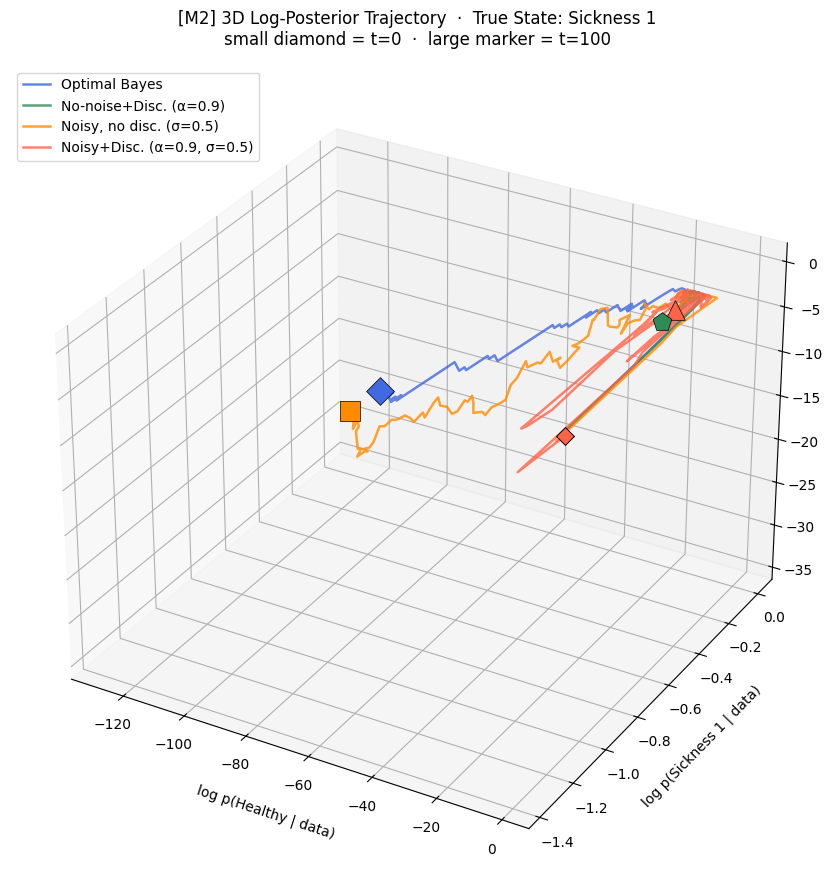

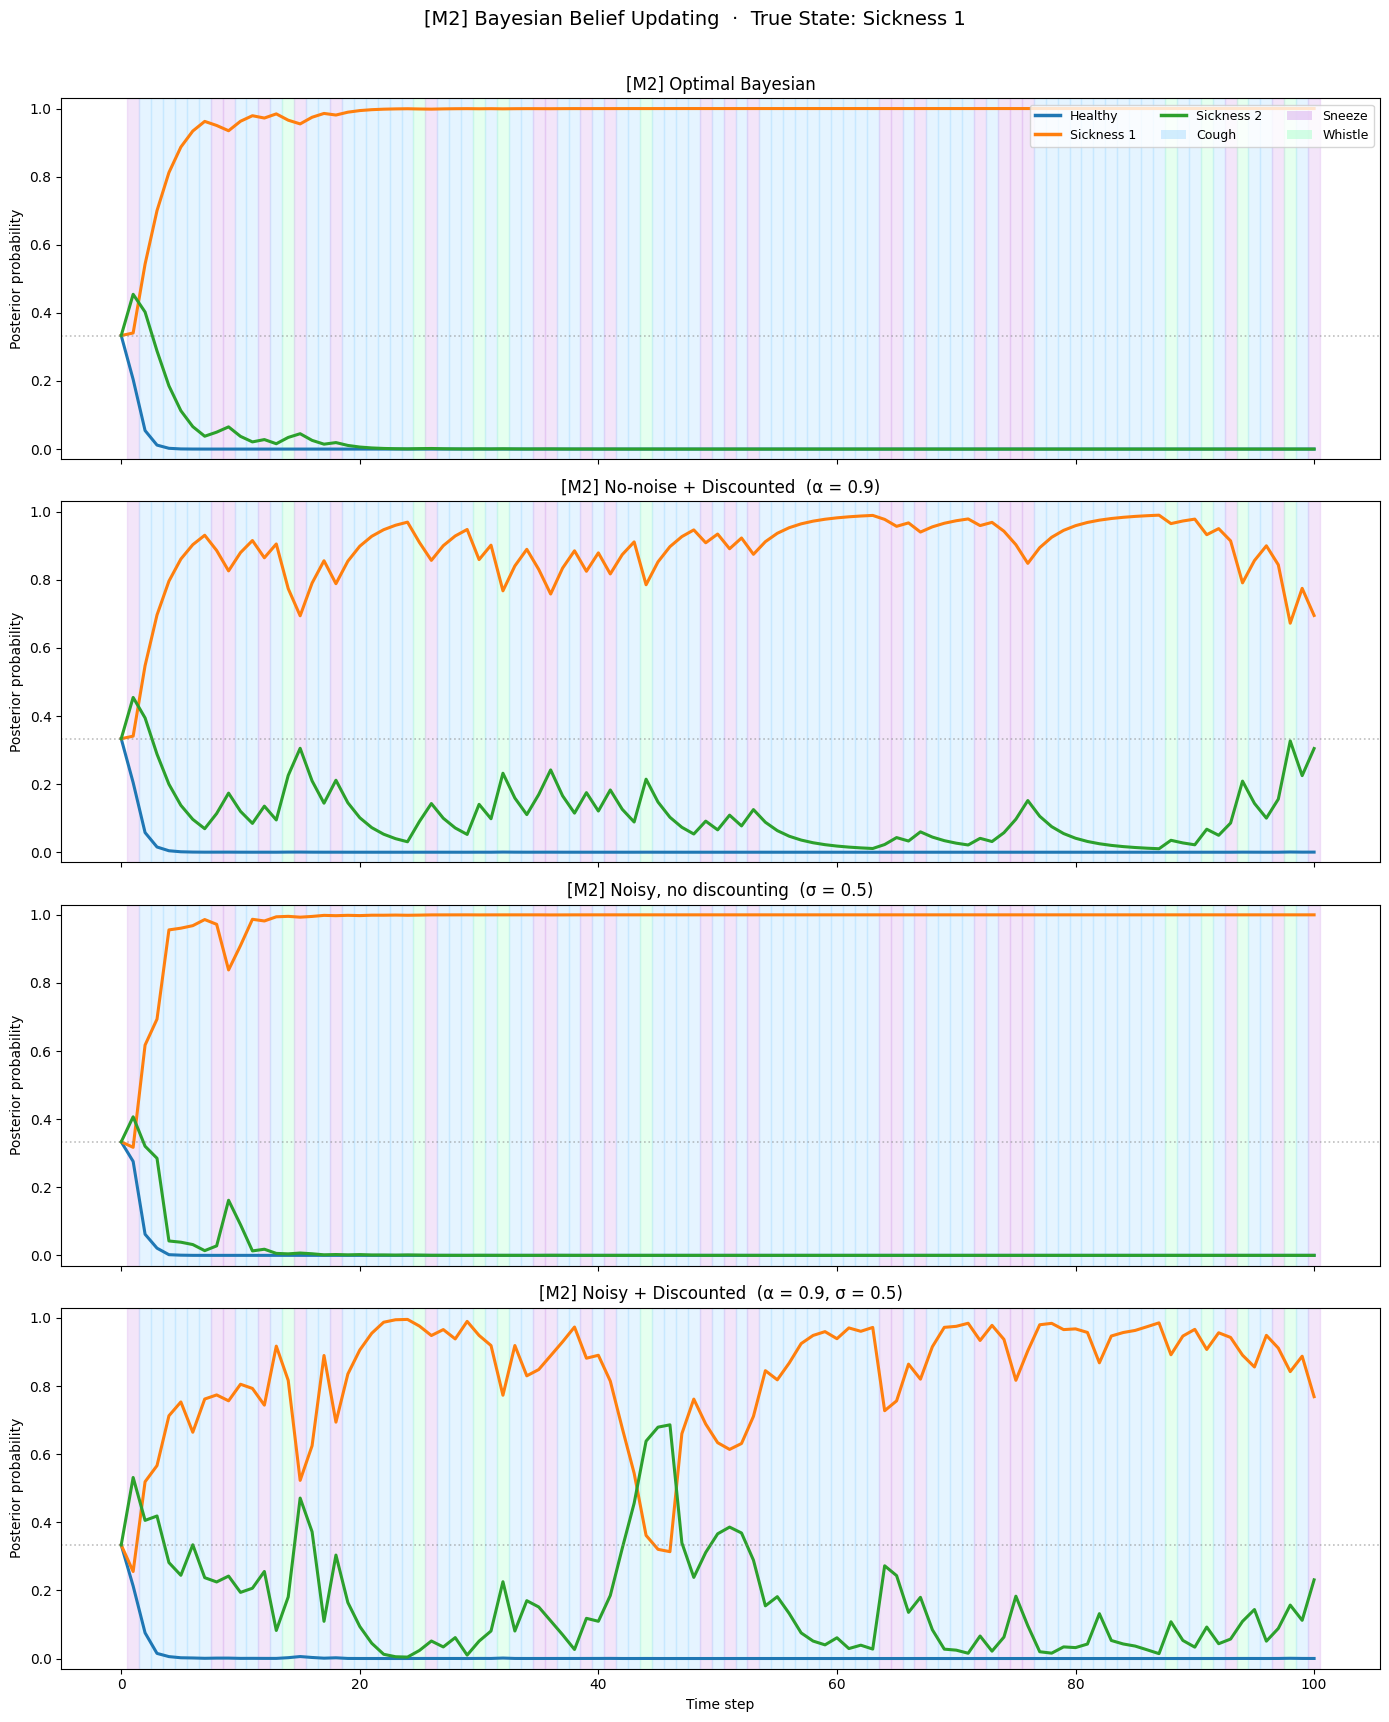

In [216]:
# ── Module 2: Engineered Neutral Sick2 ──────────────────────────────────────
# Fresh variables only — norm_log, T, SIGMA, ALPHA reused from above.

M2_TRUE_S = 1

#                Healthy  Sick1        Sick2
L2 = np.array([[0.10,    0.60,        1/3],   # Cough
               [0.15,    0.25,        1/3],   # Sneeze
               [0.75,    0.15,        1/3]])  # Whistle

assert np.allclose(L2.sum(axis=0), 1.0), "L2 columns must sum to 1"
assert np.all(L2 > 0)

m2_prior     = np.array([1/3, 1/3, 1/3])
m2_log_prior = norm_log(np.log(m2_prior))
m2_times     = np.arange(T + 1)

m2_rng_data  = np.random.default_rng(17)
m2_obs       = m2_rng_data.choice(3, size=T, p=L2[:, M2_TRUE_S])

print('Module 2 — Engineered Neutral Sick2')
print(f'True state : {STATES[M2_TRUE_S]}')
print(f'Symptom counts — Cough: {(m2_obs==0).sum()}, Sneeze: {(m2_obs==1).sum()}, Whistle: {(m2_obs==2).sum()}')
print('\nLikelihood matrix L2 (columns = states):')
print('         ', '  '.join(f'{s:>10}' for s in STATES))
for i, sym in enumerate(SYMPTOMS):
    print(f'{sym:<8}', '  '.join(f'{L2[i,j]:>10.4f}' for j in range(3)))

# ── Model 1: Optimal Bayesian ─────────────────────────────────────────────────
m2_lb_opt    = np.zeros((T + 1, 3)); m2_lb_opt[0] = m2_log_prior
for t in range(1, T + 1):
    m2_lb_opt[t] = norm_log(m2_lb_opt[t - 1] + np.log(L2[m2_obs[t - 1]]))

# ── Model 2: No-noise + Discounted ────────────────────────────────────────────
m2_lb_disc   = np.zeros((T + 1, 3)); m2_lb_disc[0] = m2_log_prior
m2_disc      = np.zeros(3)
for t in range(1, T + 1):
    m2_disc      = np.log(L2[m2_obs[t - 1]]) + ALPHA * m2_disc
    m2_lb_disc[t] = norm_log(m2_log_prior + m2_disc)

# ── Model 3: Noisy, no discounting ────────────────────────────────────────────
m2_rng1      = np.random.default_rng(200)
m2_lb_noisy  = np.zeros((T + 1, 3)); m2_lb_noisy[0] = m2_log_prior
for t in range(1, T + 1):
    m2_lb_noisy[t] = norm_log(m2_lb_noisy[t - 1]
                               + np.log(L2[m2_obs[t - 1]])
                               + m2_rng1.normal(0, SIGMA, 3))

# ── Model 4: Noisy + Discounted ───────────────────────────────────────────────
m2_rng2      = np.random.default_rng(300)
m2_lb_nd     = np.zeros((T + 1, 3)); m2_lb_nd[0] = m2_log_prior
m2_disc_n    = np.zeros(3)
for t in range(1, T + 1):
    m2_disc_n    = (np.log(L2[m2_obs[t - 1]]) + m2_rng2.normal(0, SIGMA, 3)) + ALPHA * m2_disc_n
    m2_lb_nd[t]  = norm_log(m2_log_prior + m2_disc_n)

m2_models = [
    (m2_lb_opt,   'Optimal Bayes',                      'royalblue',  'D'),
    (m2_lb_disc,  f'No-noise+Disc. (α={ALPHA})',         'seagreen',   'p'),
    (m2_lb_noisy, f'Noisy, no disc. (σ={SIGMA})',        'darkorange', 's'),
    (m2_lb_nd,    f'Noisy+Disc. (α={ALPHA}, σ={SIGMA})', 'tomato',     '^'),
]

print(f'\nFinal posteriors at t={T}:')
for lb, label, *_ in m2_models:
    print(f'  {label:<40} final: {np.exp(lb[-1]).round(3)}')

# ── 3D log-posterior trajectory ───────────────────────────────────────────────
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')
for lb, label, col, mk in m2_models:
    ax.plot(lb[:, 0], lb[:, 1], lb[:, 2], label=label, color=col, alpha=0.80, lw=1.8)
    ax.scatter(*lb[0],  color=col, marker='D', s=80,  zorder=5, edgecolors='k', lw=0.5)
    ax.scatter(*lb[-1], color=col, marker=mk,  s=200, zorder=5, edgecolors='k', lw=0.5)
ax.set_xlabel('log p(Healthy | data)',     labelpad=10)
ax.set_ylabel('log p(Sickness 1 | data)', labelpad=10)
ax.set_zlabel('log p(Sickness 2 | data)', labelpad=10)
ax.set_title(f'[M2] 3D Log-Posterior Trajectory  ·  True State: {STATES[M2_TRUE_S]}\n'
             'small diamond = t=0  ·  large marker = t=100', pad=15)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# ── 2D posterior probability traces ──────────────────────────────────────────
m2_state_cols   = ['tab:blue', 'tab:orange', 'tab:green']
m2_symptom_cols = ['#AADDFF', '#D8AAEE', '#AAFFCC']

fig, axes = plt.subplots(4, 1, figsize=(14, 17), sharex=True)
m2_model_cfg = [
    (m2_lb_opt,   'Optimal Bayesian'),
    (m2_lb_disc,  f'No-noise + Discounted  (α = {ALPHA})'),
    (m2_lb_noisy, f'Noisy, no discounting  (σ = {SIGMA})'),
    (m2_lb_nd,    f'Noisy + Discounted  (α = {ALPHA}, σ = {SIGMA})'),
]
for ax, (lb, title) in zip(axes, m2_model_cfg):
    for t_i, x_i in enumerate(m2_obs):
        ax.axvspan(t_i + 0.5, t_i + 1.5, color=m2_symptom_cols[x_i], alpha=0.30)
    probs = np.exp(lb)
    for s, (state, col) in enumerate(zip(STATES, m2_state_cols)):
        ax.plot(m2_times, probs[:, s], label=state, color=col, lw=2.2)
    ax.axhline(1/3, color='gray', ls=':', alpha=0.5, lw=1.2)
    ax.set_ylabel('Posterior probability')
    ax.set_title(f'[M2] {title}', fontsize=12)
    ax.set_ylim(-0.03, 1.03)

m2_state_lines = [plt.Line2D([0],[0], color=c, lw=2.5, label=s)
                  for c, s in zip(m2_state_cols, STATES)]
m2_sym_patches = [mpatches.Patch(facecolor=c, alpha=0.5, label=s)
                  for c, s in zip(m2_symptom_cols, SYMPTOMS)]
axes[0].legend(handles=m2_state_lines + m2_sym_patches, loc='upper right', ncol=3, fontsize=9)
axes[-1].set_xlabel('Time step')
plt.suptitle(f'[M2] Bayesian Belief Updating  ·  True State: {STATES[M2_TRUE_S]}',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()